### xgb_ranker

In this notebook, we attempt to predict nomination-worthy novels using a year-by-year Learn-To-Rank model with XGBRanker.

In [20]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn
import sys

sys.path.append("../scripts")

In [21]:
books_tt = pd.read_csv('../data/books_engineered_train.csv')
books_tt.head()

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,0,0
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,0,0
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,0,0
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
sys.path.append("../scripts")
from feature_engineering.feature_engineering import tag_dataframe
from custom_yearly_scalers import YearByYearStandardScaler, YearlyGenreTagScaler, YearlyPastNomineeSimilarityScaler, bool_to_integer
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('bool_to_int', FunctionTransformer(bool_to_integer, feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])    ],
)

We shall use **walk-forward nested time series cross-validation**.

In [23]:
from walkforward_cv import walk_forward

windows = walk_forward(books_tt)


In [24]:
features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

import xgboost as xgb

model =  Pipeline(steps=[
        ('preprocess', feature_preprocessing),
        ('xgb_rank', xgb.XGBRanker(
    tree_method="hist",
    objective="rank:ndcg",
    eval_metric="ndcg",
    lambdarank_pair_method="topk",

    # determined through some hyperparameter iterations.
    lambdarank_num_pair_per_sample=250, 
    max_depth=5,                       
    learning_rate=0.05,
    n_estimators=300,                  
    colsample_bytree=0.7,              
    subsample=0.8
))
])

We train the XGBRanker to rank the books in order of likelihood to be part of the nominee/finalists. Since we do not know the number of nominees in a given year, as this has varied historically, we validate by checking precision-at-k: given the fact that there are k positives in a given year, how well do the top k ranked books match?

Here, then, precision and recall will be mathematically equal; we only plot f1 score.

We can also compare precision @ 10, precision @ 15, precision @ 20: to see what the predictive power of the model is, to predict the top books most likely to be nominated.

In [25]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, ndcg_score, recall_score, average_precision_score

cv_data = []

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()
    year = book_val['release_year'].mode()

    model.fit(
                book_train[features],
                book_train['target'],
                xgb_rank__qid=book_train['release_year'],
            )
    
    ypred = model.predict(book_val[features])
    book_val['predicted_score'] = ypred

    book_val['rank_within_year'] = book_val.groupby('release_year')['predicted_score'].rank(
            method='first', 
            ascending=False
        )

    # get the number of finalists in that year
    num_finalists = book_val['target'].values.astype(int).sum()

    # set top values to be true, rest false
    book_val['predicted_k'] = (book_val['rank_within_year'] <= num_finalists).astype(int)
    book_val['predicted_10'] = (book_val['rank_within_year'] <= 10).astype(int)
    book_val['predicted_15'] = (book_val['rank_within_year'] <= 15).astype(int)
    book_val['predicted_20'] = (book_val['rank_within_year'] <= 20).astype(int)

    f1score = f1_score(book_val['target'], book_val['predicted_k'].values)
    precision10 = precision_score(book_val['target'], book_val['predicted_10'].values)
    precision15 = precision_score(book_val['target'], book_val['predicted_15'].values)
    precision20 = precision_score(book_val['target'], book_val['predicted_20'].values)

    cv_data.append({'fold': num, "val_year": year.values, 'f1_score': f1score, 'precision_10': precision10, 
    'precision_15': precision15,'precision_20': precision20})

# axes[0].set_ylabel('predicted score')
# axes[0].legend()
# plt.tight_layout()
# plt.show()


In [26]:
cv_result = pd.DataFrame(cv_data)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.5267506488751444
STD of f1 score across folds:  0.07769761564613589


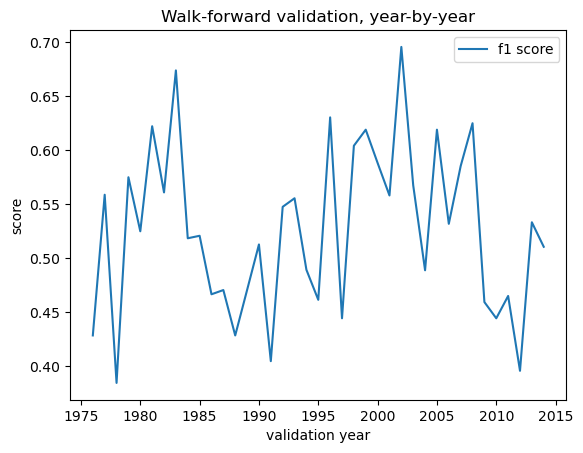

In [27]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
# plt.plot([year[0] for year in cv_result['val_year']], cv_result['prc_auc'], label='precision-top')
counts = book_train[book_train['target']==True].groupby('release_year')['title'].count()
# plt.scatter(counts.index, counts.values/max(counts.values))

plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

<Axes: >

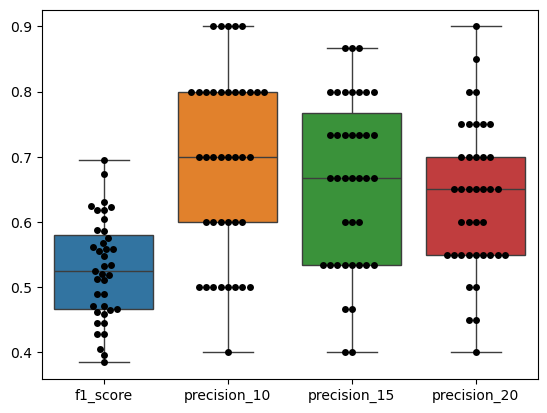

In [10]:
import seaborn as sns

ax = sns.boxplot(data=cv_result[['f1_score', 'precision_10', 'precision_15', 'precision_20']])

sns.swarmplot(data=cv_result[['f1_score', 'precision_10', 'precision_15', 'precision_20']], ax=ax, color='black')


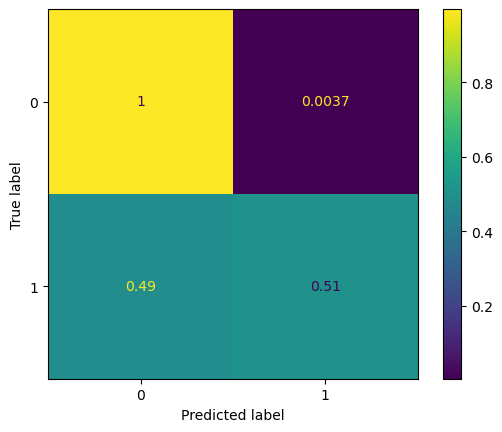

In [11]:
conf = confusion_matrix(book_val['target'], book_val['predicted_k'], normalize='true')

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=conf).plot()


Let us look at the most important features.

In [12]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()

importances = model.named_steps['xgb_rank'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                              Feature  Importance
3      numerical_scaling__years_since_last_nomination    0.246392
0          numerical_scaling__Total_Awards_Previously    0.175654
81         nominee_similarity__past_winner_similarity    0.050706
46                  onehot__first_publisher_orbit(us)    0.050303
4   numerical_scaling__publisher_historical_nomina...    0.028669
80                 tag_similarity__cohort_similiarity    0.027717
32                   onehot__first_publisher_gollancz    0.023321
2                 numerical_scaling__author_num_books    0.023077
19              onehot__first_publisher_bantamspectra    0.020699
28                       onehot__first_publisher_dell    0.020130
63                        onehot__first_publisher_tor    0.019767
45                      onehot__first_publisher_orbit    0.019249
1        numerical_scaling__Author_Age_at_Publication    0.016914
18                onehot__first_publisher_bantambooks    0.015947
48        

The fact that these models are so reliant on the # of total awards and the # of years since last nomination implies that they might overlookbooks by authors who have not previously been nominated. Let's see.

In [13]:
identified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted_k'] == 1)]
unidentified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted_k'] == 0)]

In [14]:
identified_noms['NomineeBefore'].value_counts()

NomineeBefore
True    24
Name: count, dtype: int64

In [15]:
unidentified_noms['NomineeBefore'].value_counts()

NomineeBefore
False    14
True      9
Name: count, dtype: int64

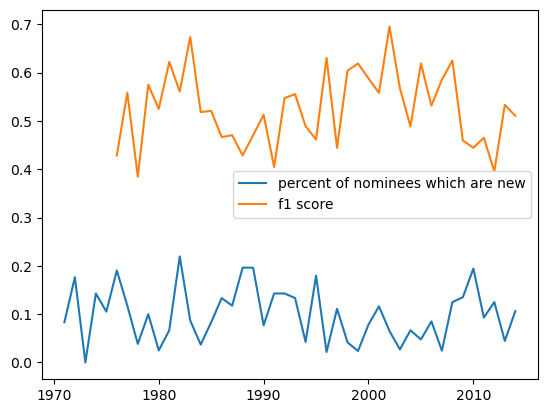

In [16]:
newbie_count = books_tt[books_tt['target']].groupby('release_year')['new_author'].sum()
all_count = books_tt[books_tt['target']].groupby('release_year')['title'].count()

years = newbie_count.index.values
values = newbie_count.values

plt.plot(years, values/all_count.values, label = 'percent of nominees which are new')
# plt.plot(years, values/np.max(values), label = 'new nominees normalized')

plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')

plt.plot()
plt.legend()


It is not immediately clear that these are related..

### Improving on New author training

can we change anything about these features to try and improve this?

In [110]:
books_tt_copy = books_tt.copy()
books_tt_copy = books_tt_copy[books_tt_copy['new_author']]
books_tt_copy['author_success_fraction'] = books_tt_copy['Total_Awards_Previously'] / books_tt_copy['author_num_books']

numerical_features = ["Author_Age_at_Publication", 'publisher_historical_nominations']
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('bool_to_int', FunctionTransformer(lambda x: x.astype(int), feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])    ],
)

In [ ]:
model2 =  Pipeline(steps=[
        ('preprocess', feature_preprocessing),
        ('xgb_rank', xgb.XGBRanker(
    tree_method="hist",
    objective="rank:ndcg",
    eval_metric="ndcg",
    lambdarank_pair_method="topk",

    # determined through some hyperparameter iterations.
    lambdarank_num_pair_per_sample=50, 
    max_depth=5,                       
    learning_rate=0.05,
    n_estimators=300,                  
    colsample_bytree=0.7,              
    subsample=0.8
))
])

windows2 = walk_forward(books_tt_copy)

In [142]:
cv_data = []

for num, fold in enumerate(windows2):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()
    year = book_val['release_year'].mode()

    model2.fit(
                book_train[features],
                book_train['target'],
                xgb_rank__qid=book_train['release_year'],
            )
    
    ypred = model2.predict(book_val[features])
    book_val['predicted_score'] = ypred

    book_val['rank_within_year'] = book_val.groupby('release_year')['predicted_score'].rank(
            method='first', 
            ascending=False
        )
    
    num_finalists = book_val['target'].values.astype(int).sum()

    # set top values to be true, rest false
    book_val['predicted_k'] = (book_val['rank_within_year'] <= num_finalists).astype(int)

    precision = precision_score(book_val['target'], book_val['predicted_k'].values)

    cv_data.append({'fold': num, "val_year": year.values, 'precision': precision, 'num_finalists': num_finalists})
    # print(num)

In [144]:
cv_result = pd.DataFrame(cv_data)
print("Mean precision score across folds: ", cv_result['precision'].mean())
print("STD of precision score across folds: ", cv_result['precision'].std())

Mean precision score across folds:  0.16017686017686017
STD of precision score across folds:  0.19014585553370156


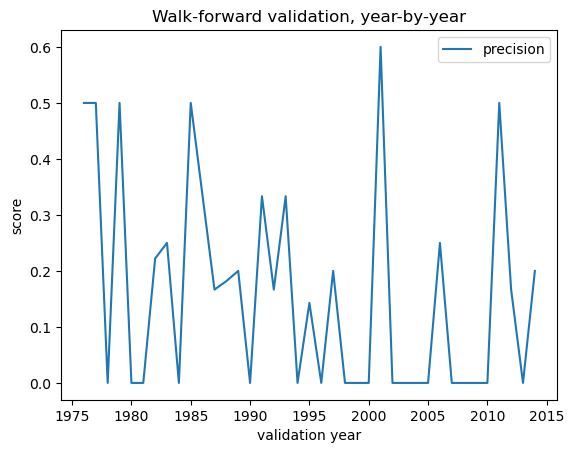

In [145]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')

plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

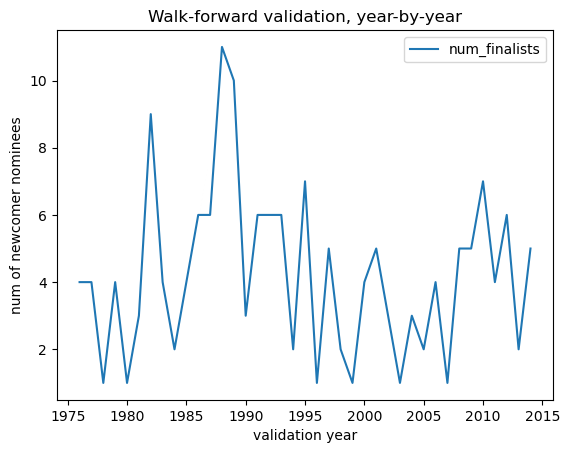

In [146]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['num_finalists'], label='num_finalists')
plt.xlabel("validation year")
plt.ylabel("num of newcomer nominees")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

The ranker performs a lot worse on the training set which consists only of "debut" nominees. There isn't a clear correlation between # of debut nominees and score, but the small # each year means there is a very small sample for the ranker to learn from.

We save the full ranker.

In [17]:
import joblib

export_path = 'trained_models/'

joblib.dump(model, export_path + "xgbranker_model.pkl") 

['trained_models/xgbranker_model.pkl']